## Imports

In [ ]:
import pandas as pd
import geopandas as gpd
import numpy as np
import pymc as pm
import arviz as az
import libpysal
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from cmdstanpy import CmdStanModel
from numba import njit
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, leaves_list
from sklearn.cluster import AgglomerativeClustering
import os
import json
import shutil
import urllib.request
import pandas as pd
from scipy.linalg import eigvalsh




'cmdstan-2.36.0'

### Google Colab 

In [ ]:
# if colab is necessary

# Install pre-built CmdStan binary
# (faster than compiling from source via install_cmdstan() function)
tgz_file = 'colab-cmdstan-2.36.0.tar.gz'
tgz_url = 'https://github.com/stan-dev/cmdstan/releases/download/v2.36.0/colab-cmdstan-2.36.0.tgz'
if not os.path.exists(tgz_file):
    urllib.request.urlretrieve(tgz_url, tgz_file)
    shutil.unpack_archive(tgz_file)

# Specify CmdStan location via environment variable
os.environ['CMDSTAN'] = './cmdstan-2.36.0'
# Check CmdStan path
from cmdstanpy import CmdStanModel, cmdstan_path
cmdstan_path()

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATA_PATH = "/content/drive/MyDrive/Colab_Notebooks/updated_data.geojson"
df = gpd.read_file(DATA_PATH)

### Local Runtime

In [ ]:
DATA_PATH = "../data/updated_data_v2.geojson"
df = gpd.read_file(DATA_PATH)

## Data and spatial weights

In [ ]:
y = df["fem_empl_rate"].to_numpy()
y = y / 100
y_star = np.log(y / (1 - y))

selected_covariates = ["coverage", "young_neet", "fertility_rate", 'fem_house_rate']
X = df[selected_covariates].to_numpy()
X_scaler = StandardScaler()
X_star = X_scaler.fit_transform(X)

N = 107
P = len(selected_covariates)
K = 15

In [ ]:
W_obj = libpysal.weights.Queen.from_dataframe(df)
adj = W_obj.to_adjlist(remove_symmetric=True)

# 1-based indexing for Stan
node1 = adj["focal"].values + 1
node2 = adj["neighbor"].values + 1
N_edges = len(node1)
W_dense = W_obj.full()[0] # full adja
num_neighbors = W_dense.sum(axis=1).astype(int)

/tmp/ipython-input-939002290.py:1: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  W_obj = libpysal.weights.Queen.from_dataframe(df)
/usr/local/lib/python3.12/dist-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)
/tmp/ipython-input-939002290.py:2: DeprecationWarning: In the next version of libpysal, observations with no neighbors will be included in adjacency lists as loops (row with the same focal and neighbor) with zero weight. In the current version, observations with no neighbors are dropped. If you would like to keep the current behavior, use drop_islands=True in this function
  adj = W_obj.to_adjlist(remove_symmetric=True)


## STAN model

### Actual model

In [ ]:
sparse_mix_model = """
functions {
  real sparse_car_leroux_lpdf(
    vector phi,
    real tau,
    real rho,
    array[] int node1,
    array[] int node2,
    vector n_neighbors,
    vector lambda,
    int N,
    int N_edges
  ) {
    real phi_W_phi = 0;
    for (i in 1:N_edges) {
      phi_W_phi += phi[node1[i]] * phi[node2[i]];
    }
    phi_W_phi *= 2;

    real phi_D_phi = dot_product(n_neighbors, phi .* phi);
    real phi_phi = dot_product(phi, phi);

    real quad = rho * (phi_D_phi - phi_W_phi) + (1 - rho) * phi_phi;

    real log_det = 0;
    for (i in 1:N) {
      log_det += log(rho * lambda[i] + (1 - rho));
    }

    return 0.5 * (N * log(tau) + log_det - tau * quad);
  }
}

data {
  int<lower=1> N;
  int<lower=1> P;
  int<lower=1> K;
  int<lower=1> N_edges;

  vector[N] y_star;
  matrix[N, P] X_star;

  // Sparse inputs
  array[N_edges] int<lower=1, upper=N> node1;
  array[N_edges] int<lower=1, upper=N> node2;
  vector[N] n_neighbors; // I pass this in Python (replaces D)
  vector[N] lambda;      // I also pass this in Python (replaces lambda_eig)

  // Hyperparameters
  real<lower=0> e0;
  real<lower=0> nu1;
  real<lower=0> nu2;
}

// NO 'transformed data' BLOCK: I pass D and lambda)

parameters {
  simplex[K] pi;

  real alpha;
  matrix[K, P] beta;

  vector<lower=0>[P] lambda_sq;
  vector[P] b0;

  real<lower=1e-6> sigma;
  real<lower=1e-6> tau;
  vector[N] phi_raw;
  real<lower=0, upper=0.99> rho;
}

transformed parameters {
  vector[N] phi;
  phi = phi_raw - mean(phi_raw); //is this necessary?

  vector[P] lambda_scale = sqrt(lambda_sq);
}

model {
  // --- 1. PRIORS ---
  pi ~ dirichlet(rep_vector(e0, K));
  lambda_sq ~ gamma(nu1, nu2);
  b0 ~ normal(0,2);

  for (j in 1:P) {
    beta[:, j] ~ normal(b0[j], lambda_scale[j]);
  }

  alpha ~ normal(0, 2);
  tau  ~ gamma(2, 1);
  rho   ~ beta(1,1);
  sigma ~ inv_gamma(2, 1);

  // --- 2. SPATIAL RANDOM EFFECTS ---
  phi_raw ~ sparse_car_leroux(tau, rho, node1, node2, n_neighbors, lambda, N, N_edges);

  // --- 3. LIKELIHOOD ---
  for (i in 1:N) {
    vector[K] lps;
    for (k in 1:K) {
      real mu_ik;
      mu_ik = alpha + dot_product(row(X_star, i), beta[k]) + phi[i];
      lps[k] = log(pi[k]) + normal_lpdf(y_star[i] | mu_ik, sigma);
    }
    target += log_sum_exp(lps);
  }
}

generated quantities {
  array[N] int z;
  vector[P] variable_relevance;

  variable_relevance = lambda_sq;

  for (i in 1:N) {
    vector[K] lps;
    vector[K] r_i;
    for (k in 1:K) {
      real mu_ik = alpha + dot_product(row(X_star, i), beta[k]) + phi[i];
      lps[k] = log(pi[k]) + normal_lpdf(y_star[i] | mu_ik, sigma);
    }
    r_i = softmax(lps);
    z[i] = categorical_rng(r_i);
  }
}
"""

In [ ]:
with open("sparse_mix_model.stan", "w") as f:
    f.write(sparse_mix_model)

### Stan data

In [ ]:
# "adjacency data" -> sparse structure instead of W.full()[0]
node1 = adj["focal"].values + 1     # need 1 based indexing
node2 = adj["neighbor"].values + 1  # same as above
N_edges = len(node1)
num_neighbors = W_dense.sum(axis=1) # Or calculate from adj if W_dense is too big

# eigenvalues of M = D - W
# (where D is diagonal matrix of neighbor counts)
D = np.diag(num_neighbors)
M = D - W_dense
eigenvalues = eigvalsh(M)
stan_data = {
    "N": int(N),
    "P": int(P),
    "K": int(K),
    "N_edges": int(N_edges),
    "y_star": y_star,
    "X_star": X_star,

    # spatial structure
    "node1": node1.astype(int),
    "node2": node2.astype(int),
    "n_neighbors": num_neighbors.astype(float),
    "lambda": eigenvalues.astype(float), # Pass eigenvalues directly

    # hyperparameters
    "e0": 0.5, # this was 0.01 previously
    "nu1": 0.5, # this are to shrink coefficeints to global means
    "nu2": 0.5  # 0.5 are found in the paper
}

chain 1:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

Exception: gamma_lpdf: Random variable[2] is inf, but must be positive finite! (in 'sparse_mix_model.stan', line 82, column 2 to column 30)
Consider re-running with show_console=True if the above output is unclear!


	Chain 1 had 1952 divergent transitions (97.6%)
	Chain 2 had 1974 divergent transitions (98.7%)
	Chain 2 had 4 iterations at max treedepth (0.2%)
	Chain 3 had 1972 divergent transitions (98.6%)
	Chain 4 had 1942 divergent transitions (97.1%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


In [ ]:
# Compile and Sample
model = CmdStanModel(stan_file="sparse_mix_model.stan")

fit = model.sample(
    data=stan_data,
    chains=4,
    iter_warmup=2000,
    iter_sampling=2000,
    adapt_delta=0.95,
    max_treedepth=12
)

In [ ]:
fit.diagnose()

"Checking sampler transitions treedepth.\n4 of 2000 (0.20%) transitions hit the maximum treedepth limit of 12, or 2^12 leapfrog steps.\nTrajectories that are prematurely terminated due to this limit will result in slow exploration.\nFor optimal performance, increase this limit.\n\nChecking sampler transitions for divergences.\n7844 of 2000 (392.20%) transitions ended with a divergence.\nThese divergent transitions indicate that HMC is not fully able to explore the posterior distribution.\nTry increasing adapt delta closer to 1.\nIf this doesn't remove all divergences, try to reparameterize the model.\n\nChecking E-BFMI - sampler transitions HMC potential energy.\nThe E-BFMI, 0.07, is below the nominal threshold of 0.30 which suggests that HMC may have trouble exploring the target distribution.\nIf possible, try to reparameterize the model.\n\nRank-normalized split effective sample size satisfactory for all parameters.\n\nThe following parameters had rank-normalized split R-hat greater 

In [ ]:
fit.save_csvfiles("sparse_car_mixture")

In [ ]:
idata = az.from_cmdstanpy(
    posterior=fit,
    # Optional: include data and log_likelihood if your stan code has them
    # posterior_predictive="y_rep",
    # log_likelihood="log_lik"
)

In [ ]:
idata.to_netcdf("sparse_mix_results.nc")

'sparse_mix_results.nc'

/usr/local/lib/python3.12/dist-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")


array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}>],
       [<Axes: title={'center': 'b0'}>, <Axes: title={'center': 'b0'}>],
       [<Axes: title={'center': 'beta'}>,
        <Axes: title={'center': 'beta'}>],
       [<Axes: title={'center': 'lambda_scale'}>,
        <Axes: title={'center': 'lambda_scale'}>],
       [<Axes: title={'center': 'lambda_sq'}>,
        <Axes: title={'center': 'lambda_sq'}>],
       [<Axes: title={'center': 'phi'}>, <Axes: title={'center': 'phi'}>],
       [<Axes: title={'center': 'phi_raw'}>,
        <Axes: title={'center': 'phi_raw'}>],
       [<Axes: title={'center': 'pi'}>, <Axes: title={'center': 'pi'}>],
       [<Axes: title={'center': 'rho'}>, <Axes: title={'center': 'rho'}>],
       [<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>],
       [<Axes: title={'center': 'tau2'}>,
        <Axes: title={'center': 'tau2'}>],
       [<Axes: title={'center': 'variable_relevance'}>,
        <Axes: ti

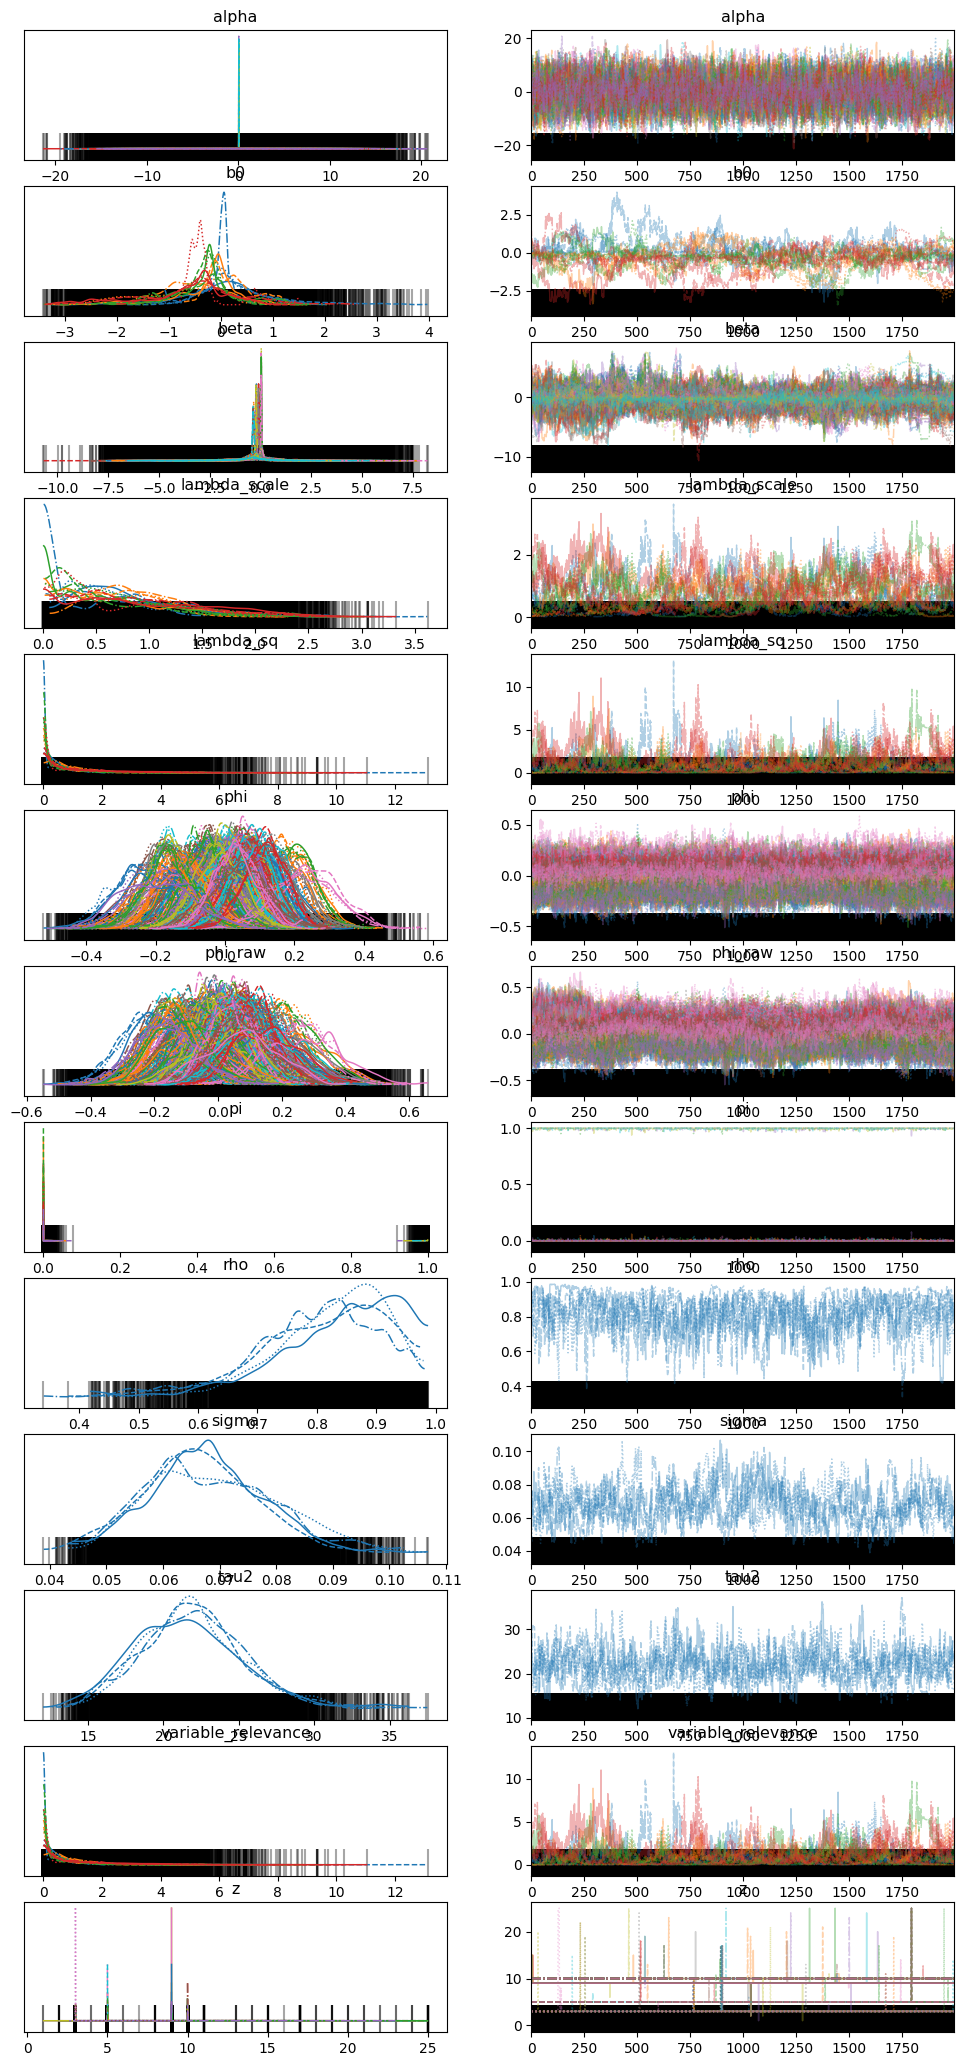

In [ ]:
az.plot_trace(idata)

In [ ]:
# check cluster specific variables:
# high value = cluster specific; near zero = global
lambdas = fit.stan_variable("variable_relevance")
cov_names = ["coverage", "young_neet", "fertility_rate", "fem_house_rate"]

print("\nMean Relevance (Lambda^2) per variable:")
for name, val in zip(cov_names, lambdas.mean(axis=0)):
    print(f"{name}: {val:.4f}")

# check number of non-empty clusters
z_draws = fit.stan_variable("z")
n_clusters_per_iter = [len(np.unique(draw)) for draw in z_draws]
print(f"\nEstimated Number of Clusters (Mode): {max(set(n_clusters_per_iter), key=n_clusters_per_iter.count)}")

## Paper's label switching solution:


In the paper, the researchers do not force the intercept term to be ordered, instead they allow for label switching and subsequently post-process the cluster allocation.

**Main Steps**
1. **Remove ordered intercepts** <br>
First, remove the ordered constraint in your Stan code so the MCMC sampler can explore the parameter space freely.Change: ordered[K] alpha $\rightarrow$ vector[K] alphaResult: The raw output will now have "label switching" (Cluster 1 in one iteration might be Cluster 2 in the next), which we will fix in Python.

2. **Post-Processing Script** <br>
The paper's method involves extracting the draws, identifying the "true" number of clusters, and then using a clustering algorithm on the parameter values themselves to sort them.The paper uses "K-centroids with Mahalanobis distance" to handle elliptical shapes. In Python, the standard equivalent for clustering elliptical data is a Gaussian Mixture Model (GMM) on the draws.
3. **Filtering** <br>
The paper emphasizes removing draws from "empty" components before clustering because they are just noise (sampled from the prior) and confuse the algorithm.
4. **GMM** <br>
The authors note that clustering based on simple Euclidean distance (K-means) often fails because posterior distributions are elliptical. By using a GMM (which learns a covariance matrix for each cluster), we replicate the benefit of the paper's Mahalanobis distance approach
5. **Permutation Check** <br>
This corresponds to the variable $M_{0,\rho}$ in the paper. If the clustering algorithm assigns two of your components to the same label (e.g., it thinks both Component 1 and Component 4 look like "Cluster A"), you cannot solve the label switching for that iteration, so it must be dropped.